## MSDS 686 Capstone | Drone vs Bird Classification : Baseline Models

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

DATA_RAW  = '../data/raw'
SEED      = 42
BIRD_DIR  = os.path.join(DATA_RAW, 'birds')
DRONE_DIR = os.path.join(DATA_RAW, 'drones')

# Calculate counts directly from raw files
n_birds  = len([f for f in os.listdir(BIRD_DIR)  if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
n_drones = len([f for f in os.listdir(DRONE_DIR) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
n_total  = n_birds + n_drones

print(f"Birds: {n_birds} | Drones: {n_drones} | Total: {n_total}")

Birds: 1607 | Drones: 2499 | Total: 4106


### Baseline 1 : Naive Majority Class Predictor

In [11]:
majority_acc = n_drones / n_total

print("BASELINE 1 — Naive Majority Class Predictor")
print("=" * 50)
print(f"  Strategy:  Always predict 'drone' (majority class)")
print(f"  Accuracy:  {majority_acc:.4f}  ({majority_acc*100:.1f}%)")
print(f"  AUC-ROC:   0.5000")
print()
print("  This is the absolute floor. A model that cannot beat")
print(f"  {majority_acc*100:.1f}% accuracy has learned nothing useful.")

BASELINE 1 — Naive Majority Class Predictor
  Strategy:  Always predict 'drone' (majority class)
  Accuracy:  0.6086  (60.9%)
  AUC-ROC:   0.5000

  This is the absolute floor. A model that cannot beat
  60.9% accuracy has learned nothing useful.


### Baseline 2 : Logistic Regression on Flattened Pixels

In [12]:
SMALL_SIZE  = (32, 32)
N_PER_CLASS = 750  # 750 birds + 750 drones = 1500 total, balanced

def load_images(folder, label, n, size):
    files = [f for f in os.listdir(folder)
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
    np.random.shuffle(files)
    files = files[:n]
    X, y = [], []
    for i, f in enumerate(files):
        try:
            img = Image.open(os.path.join(folder, f)).convert('RGB').resize(size)
            X.append(np.array(img).flatten())
            y.append(label)
        except Exception as e:
            print(f"  Skipped {f}: {e}")
        if (i + 1) % 100 == 0:
            cls = 'birds' if label == 0 else 'drones'
            print(f"  [{cls}] Loaded {i+1}/{n}...")
    return X, y

print("Loading images...")
t0 = time.time()
bird_X,  bird_y  = load_images(BIRD_DIR,  0, N_PER_CLASS, SMALL_SIZE)
drone_X, drone_y = load_images(DRONE_DIR, 1, N_PER_CLASS, SMALL_SIZE)

X_flat = np.array(bird_X + drone_X, dtype=np.float64) / 255.0
y_flat = np.array(bird_y + drone_y, dtype=int)

print(f"\n  Birds: {(y_flat==0).sum()} | Drones: {(y_flat==1).sum()}")
print(f"  X_flat shape: {X_flat.shape}")
print(f"  Loaded in {time.time()-t0:.1f}s")

Loading images...
  [birds] Loaded 100/750...
  [birds] Loaded 200/750...
  [birds] Loaded 300/750...
  [birds] Loaded 400/750...
  [birds] Loaded 500/750...
  [birds] Loaded 600/750...
  [birds] Loaded 700/750...
  [drones] Loaded 100/750...
  [drones] Loaded 200/750...
  [drones] Loaded 300/750...
  [drones] Loaded 400/750...
  [drones] Loaded 500/750...
  [drones] Loaded 600/750...
  [drones] Loaded 700/750...

  Birds: 750 | Drones: 750
  X_flat shape: (1500, 3072)
  Loaded in 11.2s


In [13]:
# Train/val split — validation acts as test for baseline purposes
# (acceptable for a throwaway baseline; full train/val/test split used in CNN notebooks)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_flat, y_flat, test_size=0.2, random_state=SEED, stratify=y_flat
)
print(f"Train: {X_tr.shape} | Val: {X_val.shape}")
print(f"Train — Birds: {(y_tr==0).sum()} | Drones: {(y_tr==1).sum()}")
print(f"Val   — Birds: {(y_val==0).sum()} | Drones: {(y_val==1).sum()}")

print("\nTraining Logistic Regression...")
t1 = time.time()
lr_model = LogisticRegression(max_iter=500, random_state=SEED, solver='lbfgs')
lr_model.fit(X_tr, y_tr)
print(f"Done in {time.time()-t1:.1f}s")

lr_preds = lr_model.predict(X_val)
lr_probs = lr_model.predict_proba(X_val)[:, 1]
lr_acc   = accuracy_score(y_val, lr_preds)
lr_auc   = roc_auc_score(y_val, lr_probs)

print()
print("BASELINE 2 — Logistic Regression (32x32 flattened pixels)")
print("=" * 50)
print(f"  Accuracy: {lr_acc:.4f}  ({lr_acc*100:.1f}%)")
print(f"  AUC-ROC:  {lr_auc:.4f}")
print()
print("  Any deep learning model must beat this to justify its complexity.")

Train: (1200, 3072) | Val: (300, 3072)
Train — Birds: 600 | Drones: 600
Val   — Birds: 150 | Drones: 150

Training Logistic Regression...
Done in 0.4s

BASELINE 2 — Logistic Regression (32x32 flattened pixels)
  Accuracy: 0.8267  (82.7%)
  AUC-ROC:  0.9188

  Any deep learning model must beat this to justify its complexity.


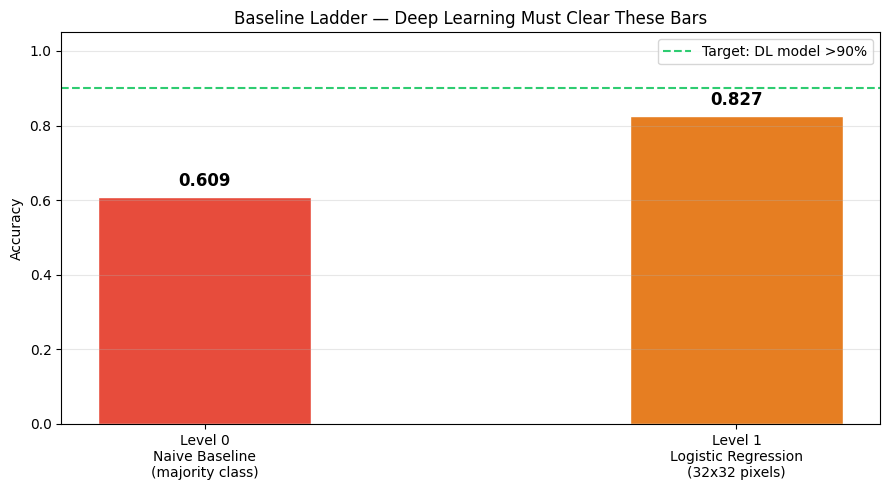

In [14]:
# ── Baseline Ladder Visualization ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

bar_labels = ['Level 0\nNaive Baseline\n(majority class)', 'Level 1\nLogistic Regression\n(32x32 pixels)']
values     = [majority_acc, lr_acc]
colors     = ['#e74c3c', '#e67e22']

bars = ax.bar(bar_labels, values, color=colors, edgecolor='white', width=0.4)
ax.bar_label(bars, fmt='%.3f', padding=5, fontsize=12, fontweight='bold')
ax.axhline(y=0.9, color='#2ecc71', linestyle='--', linewidth=1.5, label='Target: DL model >90%')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Baseline Ladder — Deep Learning Must Clear These Bars', fontsize=12)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Baseline Summary

| Baseline | Accuracy | AUC-ROC | Notes |
|----------|----------|---------|-------|
| Naive (majority class) | 60.9% | 0.500 | Always predicts 'drone', no learning |
| Logistic Regression | 82.7% | 0.919 | Raw 32x32 pixels, no spatial reasoning |

The logistic regression result of 82.7% accuracy and 0.919 AUC is surprisingly strong considering the model has no spatial reasoning. This is likely a direct consequence of the resolution gap identified in EDA, drone images are large and high-contrast but bird images are small low-resolution thumbnails. we conclude that even at 32x32, raw pixel statistics carry enough signal to partially separate the two classes.

This sets a tough floor. Our CNN must beat 82.7% accuracy and 0.919 AUC to justify its added complexity, and it must do so by learning genuine spatial features (edges, shapes, geometry) rather than just pixel brightness patterns.